<a href="https://colab.research.google.com/github/nesishaji/DL-ML-Projects/blob/main/Used_CarPrice/FinalProject4_usedCars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Introduction

The automobile industry has experienced rapid growth over the years, leading to an increase in the buying and selling of used cars. Determining the correct price of a used car is a challenging task because the value of a vehicle depends on multiple factors such as brand, manufacturing year, fuel type, mileage, transmission, engine capacity, ownership history, and overall condition. Traditional pricing methods are often based on manual estimation and market experience, which may result in inconsistent or inaccurate pricing.

With the advancement of Machine Learning and Deep Learning technologies, predictive models can now be developed to estimate used car prices more accurately and efficiently. These techniques analyze historical data and identify hidden patterns and relationships among various features affecting car prices. Accurate price prediction systems can help buyers, sellers, and dealerships make better financial decisions and improve transparency in the used car market.
This project focuses on predicting used car prices using different Machine Learning algorithms such as Linear Regression, K-Fold Cross Validation, and Decision Tree Regression, along with a Deep Learning approach using Artificial Neural Networks (ANN).

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the Used Cars dataset

df=pd.read_csv('/content/used_car_price_prediction.csv')
df.head()

,year,mileage_kmpl,engine_cc,brand,fuel_type,transmission,owner_count,accident_history,price_inr
0,2006,19.71,1279,Maruti,Diesel,Manual,3,0,39370.0
1,2019,19.52,3739,BMW,CNG,Manual,1,1,81232.0
2,2014,26.58,2407,Maruti,Electric,Automatic,1,1,80706.0
3,2010,16.64,3689,Tata,Electric,Automatic,1,0,86502.0
4,2007,10.44,3808,Maruti,Electric,Automatic,3,0,67840.0


In [ ]:
df.tail()

,year,mileage_kmpl,engine_cc,brand,fuel_type,transmission,owner_count,accident_history,price_inr
99995,2020,11.10,1481,Maruti,Petrol,Manual,3,0,35542.0
99996,2016,25.41,3387,Hyundai,CNG,Manual,2,1,42372.0
99997,2019,17.12,1263,Audi,Petrol,Manual,1,1,69638.0
99998,2018,22.19,2018,Toyota,Electric,Manual,2,0,88055.0
99999,2009,16.10,1152,Ford,Electric,Automatic,1,1,67248.0


## **2 .Understand the Data Types and Summary**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              100000 non-null  int64  
 1   mileage_kmpl      100000 non-null  float64
 2   engine_cc         100000 non-null  int64  
 3   brand             100000 non-null  object 
 4   fuel_type         100000 non-null  object 
 5   transmission      100000 non-null  object 
 6   owner_count       100000 non-null  int64  
 7   accident_history  100000 non-null  int64  
 8   price_inr         100000 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 6.9+ MB


In [ ]:
df.shape

(100000, 9)

## **3. Data cleaning**

**1. Checking null values**

In [ ]:
df.isnull().sum()

,0
year,0
mileage_kmpl,0
engine_cc,0
brand,0
fuel_type,0
transmission,0
owner_count,0
accident_history,0
price_inr,0


**2. Cheking  if in this dataset exists duplicates or not**

In [ ]:
df.duplicated().sum()

np.int64(0)

we can use **unique()** to find **distinct** values in a object data column and **value_counts()** to see the **frequency of each unique value**.

In [ ]:
print (df['brand'].unique())

['Maruti' 'BMW' 'Tata' 'Audi' 'Hyundai' 'Ford' 'Honda' 'Toyota']


In [ ]:
print (df['fuel_type'].unique())

['Diesel' 'CNG' 'Electric' 'Petrol']


In [ ]:
print (df['transmission'].unique())

['Manual' 'Automatic']


**3. Convert all object data to numerical**

In [ ]:
# Converting all the nominal datas to numerical values using labelencoder class

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [ ]:
df["brand"]=le.fit_transform(df["brand"])
df["fuel_type"]=le.fit_transform(df["fuel_type"])
df["transmission"]=le.fit_transform(df["transmission"])


In [ ]:
df.head()

,year,mileage_kmpl,engine_cc,brand,fuel_type,transmission,owner_count,accident_history,price_inr
0,2006,19.71,1279,5,1,1,3,0,39370.0
1,2019,19.52,3739,1,0,1,1,1,81232.0
2,2014,26.58,2407,5,2,0,1,1,80706.0
3,2010,16.64,3689,6,2,0,1,0,86502.0
4,2007,10.44,3808,5,2,0,3,0,67840.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              100000 non-null  int64  
 1   mileage_kmpl      100000 non-null  float64
 2   engine_cc         100000 non-null  int64  
 3   brand             100000 non-null  int64  
 4   fuel_type         100000 non-null  int64  
 5   transmission      100000 non-null  int64  
 6   owner_count       100000 non-null  int64  
 7   accident_history  100000 non-null  int64  
 8   price_inr         100000 non-null  float64
dtypes: float64(2), int64(7)
memory usage: 6.9 MB


## **Visualization**

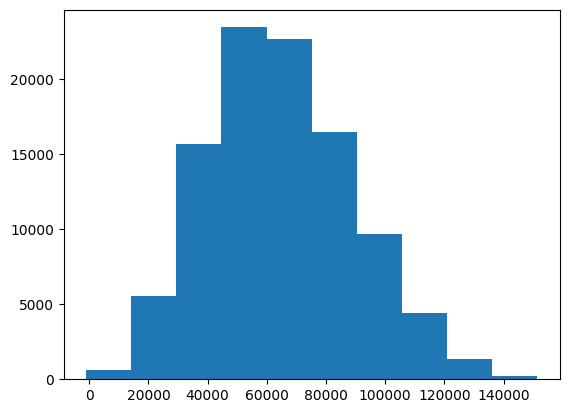

In [ ]:
plt.hist(df["price_inr"])
plt.show()

<Axes: >

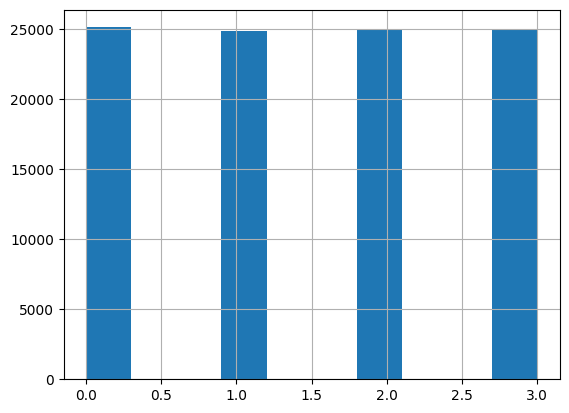

In [ ]:
df["fuel_type"].hist()

<Axes: >

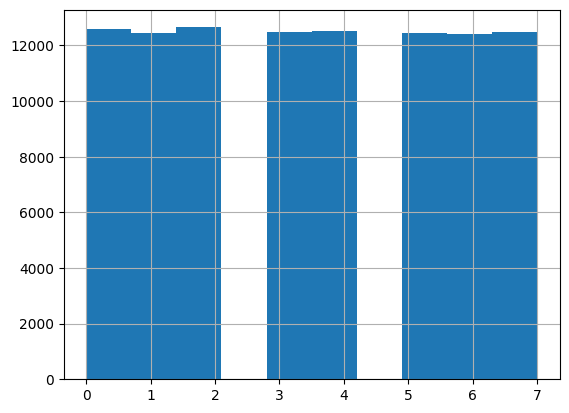

In [ ]:
df["brand"].hist()

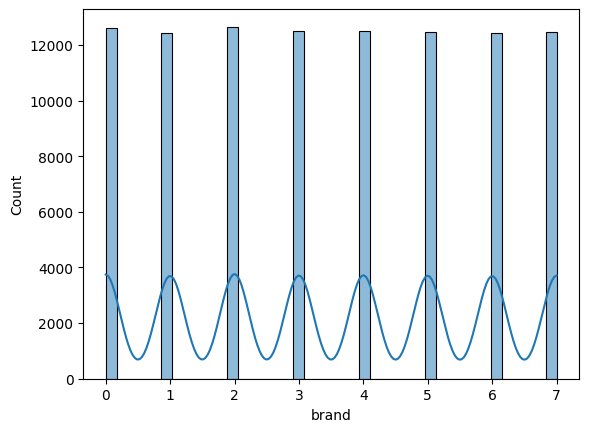

In [ ]:
sns.histplot(df['brand'], kde=True)
plt.show()

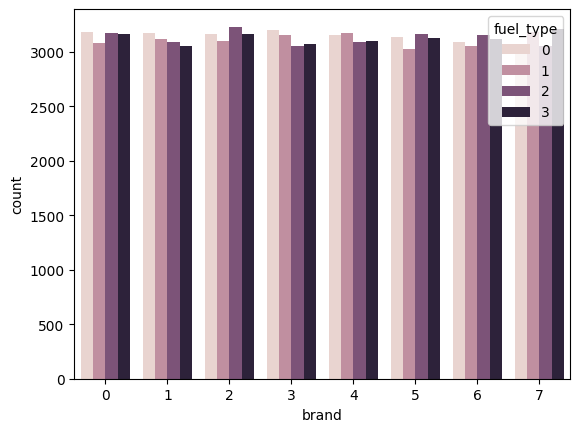

In [ ]:
sns.countplot(data=df, x='brand', hue='fuel_type')
plt.show()

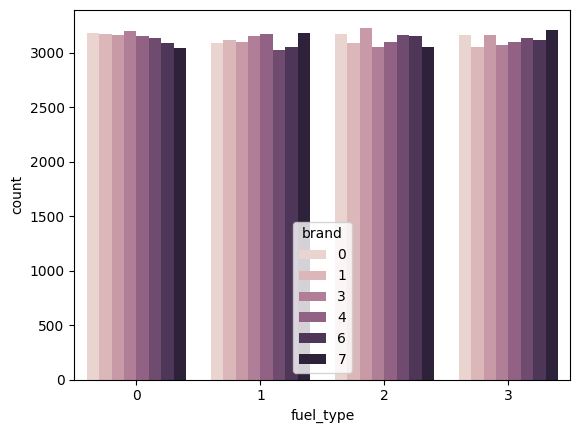

In [ ]:
sns.countplot(data=df, x='fuel_type', hue='brand')
plt.show()

### After conversion check correlation

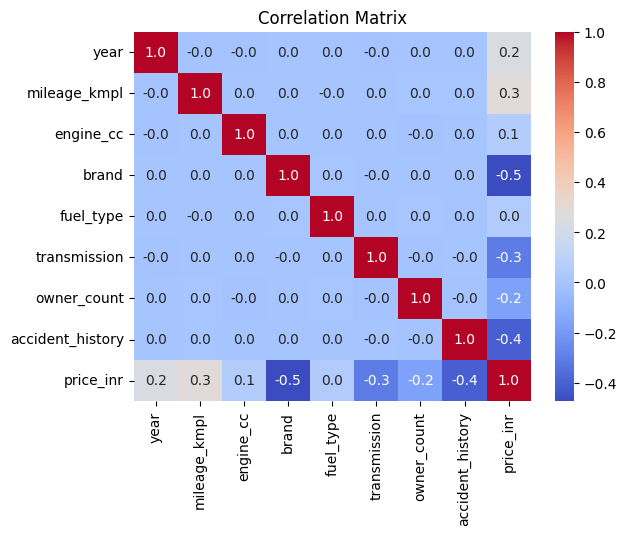

In [ ]:
# Correlation matrix
corr_matrix = df.corr()

# Heatmap of correlation matrix
sns.heatmap(corr_matrix,annot=True, fmt='0.01f', cmap='coolwarm') # 0.01f should be given for float values, d for integers
plt.title('Correlation Matrix')
plt.show()

### check : Collinearity, multicollinearity

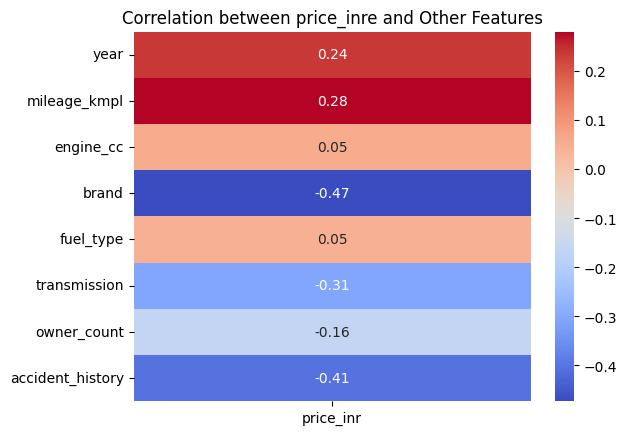

In [ ]:
# Calculate the correlation between 'price_inr' and all other columns
price_inr_corr = df.corr()['price_inr']
# Remove the correlation of 'price_inr'with itself (which is always 1)
price_inr = price_inr_corr.drop('price_inr')
# Create a heatmap to visualize the correlations
sns.heatmap(price_inr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})  # to_frame() converts Series to DataFrame for heatmap
plt.title('Correlation between price_inre and Other Features')
plt.show()

###  **Now remove less correlated**

In [ ]:
df.drop(["fuel_type", "engine_cc"],axis=1,inplace=True)

In [ ]:
df.shape

(100000, 7)

# After **EDA** we can predict

## Use LogisticRegression model if our dataset is classification (means discrete)  & if our dataset is regression (means continuous) use LinearRegression

## 1. LinearRegression

In [ ]:
# use linearRegression because our dataset is regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import pandas as pd # Import pandas

X = df[['year', 'mileage_kmpl', 'brand','transmission','owner_count','accident_history']]  # Features
y = df['price_inr']  # Target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) # You can adjust the test_size and random_state



# Train a baseline linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = model.predict(X_test)
model.score(X_test,y_test)

0.6502138805955506

## 2. KFOLD

In [ ]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
import numpy as np

In [ ]:
# Split features and target
X = df.drop('price_inr', axis=1)
y = df['price_inr']

# KFold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()

# Track best fold data
best_accuracy = 0
best_fold = -1

# Save best fold's data
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None

# Loop over each fold
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    acc = model.score(X_test,y_test)
    print(f"Fold {fold} Accuracy: {acc}")

    # Update best fold
    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred

# Output best fold details
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.647500160167503
Fold 2 Accuracy: 0.6490413672334541
Fold 3 Accuracy: 0.6517465408570584
Fold 4 Accuracy: 0.6516388916798835
Fold 5 Accuracy: 0.6501969285168555

 Best Fold: 3 with Accuracy: 0.6517465408570584


In [ ]:
model = LinearRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.6517465408570584

## 3. Decision Tree Algorithm

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd # Import pandas

# Train DecisionTree Regressor
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = model.predict(X_test)
accuracy = model.score(X_test,y_test)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.66


## 4. Support Vector Machine(SVM)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
from sklearn.pipeline import Pipeline
import pandas as pd

In [ ]:


# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',LinearSVR())
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
accuracy = model.score(X_test, y_test)
print(f'Linear SVR Pipeline accuracy: {accuracy:.2f}')

Linear SVR Pipeline accuracy: 0.66


## 5. Random Forest Regression

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

Using Random Forest Regression

In [ ]:

model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predict and evaluate the model

y_pred = model.predict(X_test)
accuracy = model.score(X_test, y_test)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.80


##**6. XG Boost**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBRegressor

In [ ]:
X = df[['year', 'mileage_kmpl', 'brand','transmission','owner_count','accident_history']]  # Features
y = df['price_inr']  # Target variable

model = XGBRegressor()
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Prediction

y_pred = model.predict(X_test)

In [ ]:
# Evaluation

accuracy = model.score(X_test, y_test)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.83


## 7. Ada Boost Regression

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

X = df[['year', 'mileage_kmpl', 'brand','transmission','owner_count','accident_history']]  # Features
y = df['price_inr']  # Target variable

Train AdaBoost model

In [ ]:
model = AdaBoostRegressor()
model.fit(X_train, y_train)

AdaBoostRegressor()

In [ ]:
# Prediction

y_pred = model.predict(X_test)

In [ ]:
# Evaluation

accuracy = model.score(X_test, y_test)
print(f'Baseline model accuracy: {accuracy:.2f}')


Baseline model accuracy: 0.75


##  8. Deep Learning

##Artificial Neural Networks (ANN)

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:


# Defining the ANN model
model = Sequential()
model.add(Dense(64, input_shape=(6,), activation='relu'))  # Hidden Layer 1
model.add(Dense(32, activation='relu'))               # Hidden Layer 2
model.add(Dense(1, ))             # Output Layer

# Compiling the model
model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 850228224.0000
Epoch 2/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 574849216.0000
Epoch 3/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 552226048.0000
Epoch 4/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 505566816.0000
Epoch 5/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 399177216.0000
Epoch 6/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 320113856.0000
Epoch 7/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 288424800.0000
Epoch 8/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 264074560.0000
Epoch 9/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 243730256.0000
Epoch 10/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 227650848.0000


In [ ]:
import numpy as np
# Evaluating the model
loss = model.evaluate(X_test, y_test)
print(f"Model Loss: {loss:.2f}")

# If you intend to calculate an accuracy-like metric for regression,
# you would typically calculate R-squared or other regression metrics separately.
# For example, using R-squared:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Model R-squared: {r2:.2f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 217436864.0000
Model Loss: 217436864.00
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model R-squared: 0.63


In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 215422848.0000
Epoch 2/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 206187056.0000
Epoch 3/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 199038464.0000
Epoch 4/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 193293792.0000
Epoch 5/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 189233088.0000
Epoch 6/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 186097888.0000
Epoch 7/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 183389504.0000
Epoch 8/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 181453984.0000
Epoch 9/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 179644880.0000
Epoch 10/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 178103520.0000
Epoch 11/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 176606800.0000
Epoch 12/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 175208080.0000
Epoch 13/100
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - los

In [ ]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Model R-squared: {r2:.2f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Model R-squared: 0.77


In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=150, batch_size=32)

Epoch 1/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 135174800.0000
Epoch 2/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 135648224.0000
Epoch 3/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 135303376.0000
Epoch 4/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 135419424.0000
Epoch 5/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 135373040.0000
Epoch 6/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 135459920.0000
Epoch 7/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 135277904.0000
Epoch 8/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 135508032.0000
Epoch 9/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 135202992.0000
Epoch 10/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 135562000.0000
Epoch 11/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 135176064.0000
Epoch 12/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 135553664.0000
Epoch 13/150
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - los

In [ ]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Model R-squared: {r2:.2f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Model R-squared: 0.77


In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=200, batch_size=32)

Epoch 1/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 134354752.0000
Epoch 2/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 134058120.0000
Epoch 3/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 133965816.0000
Epoch 4/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 134248368.0000
Epoch 5/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 134445264.0000
Epoch 6/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 134262128.0000
Epoch 7/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 134013800.0000
Epoch 8/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 134300704.0000
Epoch 9/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 134493120.0000
Epoch 10/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 134269152.0000
Epoch 11/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 134262112.0000
Epoch 12/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 134350592.0000
Epoch 13/200
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - lo

In [ ]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Model R-squared: {r2:.2f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model R-squared: 0.78


In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=300, batch_size=32)

Epoch 1/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 132233784.0000
Epoch 2/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 132077512.0000
Epoch 3/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 131754680.0000
Epoch 4/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 131876592.0000
Epoch 5/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 132045552.0000
Epoch 6/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 131936472.0000
Epoch 7/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 132149696.0000
Epoch 8/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 132013688.0000
Epoch 9/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 132114104.0000
Epoch 10/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 132022400.0000
Epoch 11/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 132101992.0000
Epoch 12/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 132145352.0000
Epoch 13/300
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - los

In [ ]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Model R-squared: {r2:.2f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Model R-squared: 0.78


# Conclusion

This project focused on predicting the prices of used cars using different Machine Learning and Deep Learning techniques, including Linear Regression, K-Fold Cross Validation, Decision Tree Regression, and Artificial Neural Networks (ANN). The objective was to analyze how accurately these models can estimate car prices based on features such as brand, fuel type, year, transmission, mileage, and engine specifications.

Among all the techniques implemented, the Artificial Neural Network (ANN) achieved the best overall performance in terms of prediction accuracy and error reduction. ANN was able to learn hidden patterns and complex relationships within the dataset more efficiently than traditional machine learning models. The deep learning approach demonstrated better generalization capability and produced more accurate used car price predictions